**Semana 13  Actividad 13: Implementación de un Autoencoder en una Red Denoising usando el dataset MNIST en Google Colab**

Actividad: Autoencoder Denoising con MNIST (Aprendizaje no supervisado)
Objetivo: Implementar y entrenar un autoencoder tipo encoder–decoder que aprenda una representación comprimida de las imágenes y sea capaz de reconstruir dígitos limpios a partir de imágenes corrompidas con ruido

**1. Carga y prepara MNIST**

(Código) Imports + reproducibilidad + carga de datos, La carga de MNIST con mnist.load_data() y el enfoque de trabajar sin labels es exactamente el planteamiento típico en autoencoders (no supervisado)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras.datasets import mnist
from keras.models import Model

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Cargar MNIST (solo imágenes; no usamos etiquetas)
(train_data, _), (test_data, _) = mnist.load_data()

print("Train:", train_data.shape, "Test:", test_data.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) Test: (10000, 28, 28)


In [3]:
# Esta preparación (normalizar + reshape a 28x28x1) sigue el patrón del ejemplo de Keras.
def preprocess(array):
    """
    Normaliza a [0,1] y reestructura a (N, 28, 28, 1)
    """
    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), 28, 28, 1))
    return array

train_data = preprocess(train_data)
test_data = preprocess(test_data)

print("Train preprocesado:", train_data.shape, "Test preprocesado:", test_data.shape)

Train preprocesado: (60000, 28, 28, 1) Test preprocesado: (10000, 28, 28, 1)


**2. Aplica ruido artificial (escenario de reconstrucción)
(Código) Función de ruido Gaussiano + clipping**

(Código) Función de ruido Gaussiano + clipping

El uso de ruido gaussiano + np.clip(..., 0, 1) es una forma estándar y aparece tal cual en el ejemplo de Keras

In [4]:
def add_noise(array, noise_factor=0.4):
    """
    Añade ruido gaussiano y recorta para mantener valores en [0,1]
    """
    noisy_array = array + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=array.shape)
    return np.clip(noisy_array, 0.0, 1.0)

noisy_train_data = add_noise(train_data, noise_factor=0.4)
noisy_test_data  = add_noise(test_data, noise_factor=0.4)

3) Visualiza: imagen original vs imagen con ruido

(Código) Función de display comparativo

Esta visualización comparativa (dos filas, original vs ruido) sigue el enfoque del ejemplo de Keras. [keras.io]

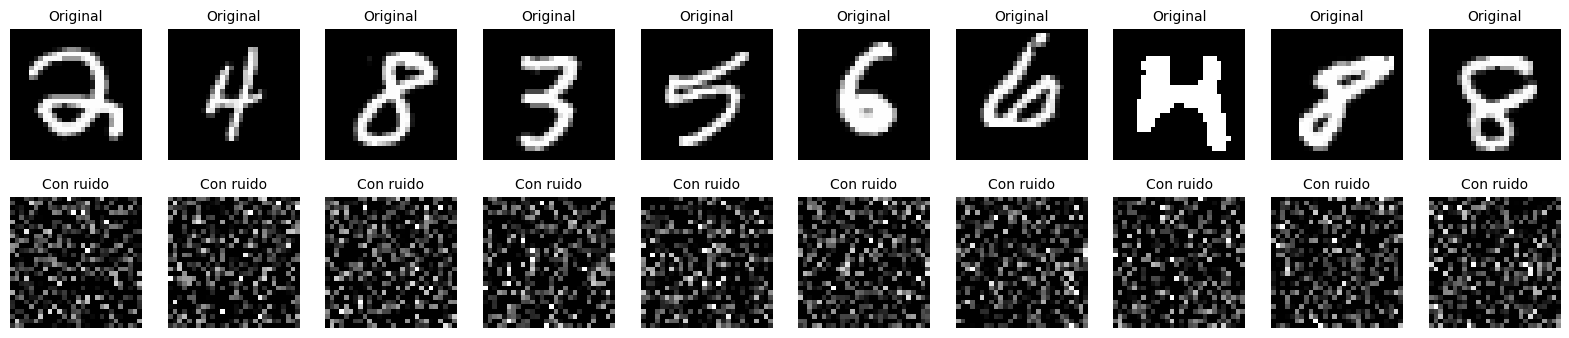

In [5]:
def display_images(array1, array2, title1="Original", title2="Con ruido", n=10):
    """
    Muestra n imágenes aleatorias: fila 1 array1, fila 2 array2
    """
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices]
    images2 = array2[indices]

    plt.figure(figsize=(2*n, 4))
    for i, (img1, img2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(img1.reshape(28, 28), cmap="gray")
        plt.title(title1, fontsize=10)
        plt.axis("off")

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(img2.reshape(28, 28), cmap="gray")
        plt.title(title2, fontsize=10)
        plt.axis("off")
    plt.show()

display_images(train_data, noisy_train_data, "Original", "Con ruido", n=10)

**4) Diseña e implementa el modelo Autoencoder Denoising (TensorFlow/Keras)**

Aquí montamos una arquitectura encoder–decoder convolucional, ideal para imágenes (capta patrones espaciales mejor que un modelo denso).

Esta arquitectura (Conv2D/MaxPool en encoder y Conv2DTranspose en decoder, con sigmoid al final) coincide con el ejemplo de Keras para denoising en MNIST.

In [8]:
# Encoder–Decoder (Autoencoder convolucional)
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(encoded)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

**5. Entrena el modelo (entrada con ruido → salida original)**

El criterio “noisy como entrada y clean como salida” es exactamente la lógica del denoising autoencoder.

In [10]:
history = autoencoder.fit(
    x=noisy_train_data,
    y=train_data,
    epochs=20,             # puedes subir a 30-50 si quieres mejor calidad
    batch_size=128,
    shuffle=True,
    validation_data=(noisy_test_data, test_data)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 255ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 251ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - loss: 0.0042 - val_loss: 0.0043
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - loss: 0.0042 - val_loss: 0.0043
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 248ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 249ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 260ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 250ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 253ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 12

(Código) Curvas de entrenamiento (loss vs val_loss)

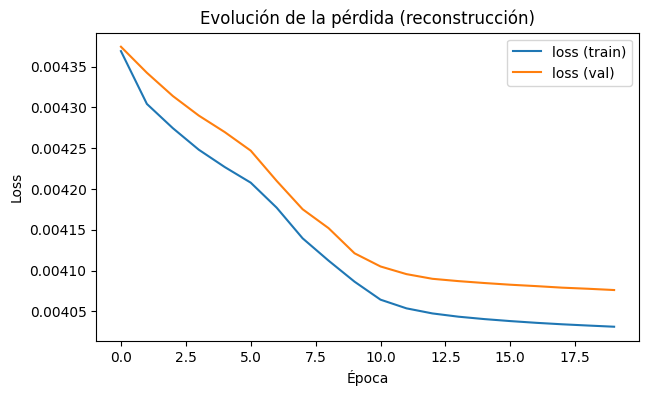

In [11]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="loss (train)")
plt.plot(history.history["val_loss"], label="loss (val)")
plt.title("Evolución de la pérdida (reconstrucción)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

**6. Evalúa desempeño: reconstrucción + comparativas**

In [12]:
reconstructed = autoencoder.predict(noisy_test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
